# 01 — Exploratory Data Analysis

This notebook explores the raw Netflix Prize dataset to understand its structure and surface patterns that will drive preprocessing and modeling decisions.

**Dataset:** Netflix Prize — ~100M ratings across ~480K users and ~17K movies (1999–2005).

**Goal:** Answer the questions that determine how to preprocess the data:
- Are all ratings valid? Are there out-of-range values?
- Do movies and users have enough interactions to be modeled?
- Is the rating distribution skewed in ways that affect model choice?
- Should we use a random or temporal train/test split?

The findings here are translated into concrete preprocessing steps in `02_preprocessing.ipynb`.

## 1. Setup

In [12]:
from pathlib import Path
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

## 2. Load Data

The Netflix Prize dataset uses a non-standard format: each file contains blocks where a movie ID appears alone on a line ending in `:`, followed by rows of `customer_id,rating,date`. We parse the 4 raw files and load them into a Polars DataFrame (memory-efficient, Arrow-backed), then convert to pandas for the analysis.

In [ ]:
ROOT          = Path('../')
RAW_DATA_PATH = ROOT / 'data' / 'raw'
NUM_RAW_FILES = 4

chunks = []
for i in range(1, NUM_RAW_FILES + 1):
    file_path = RAW_DATA_PATH / f'combined_data_{i}.txt'
    print(f"Parsing {file_path.name}...")

    movie_ids, customer_ids, ratings, dates = [], [], [], []
    current_movie_id = None

    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if line.endswith(':'):
                current_movie_id = int(line[:-1])
            else:
                try:
                    cid, r, d = line.split(',')
                    movie_ids.append(current_movie_id)
                    customer_ids.append(int(cid))
                    ratings.append(float(r))
                    dates.append(d)
                except ValueError:
                    continue

    chunks.append(pl.DataFrame({
        'movie_id':    pl.Series(movie_ids,    dtype=pl.Int32),
        'customer_id': pl.Series(customer_ids, dtype=pl.Int32),
        'rating':      pl.Series(ratings,      dtype=pl.Float32),
        'date':        pl.Series(dates,        dtype=pl.String),
    }))
    del movie_ids, customer_ids, ratings, dates
    print(f"  {len(chunks[-1]):,} rows")

df = (
    pl.concat(chunks)
      .with_columns(pl.col('date').str.to_date('%Y-%m-%d'))
      .drop_nulls('date')
      .to_pandas()
)
del chunks

# --- Movie titles ---
movie_titles_path       = RAW_DATA_PATH / 'movie_titles.csv'
movie_titles_fixed_path = RAW_DATA_PATH / 'movie_titles_fixed.csv'

if not movie_titles_fixed_path.exists():
    with open(movie_titles_path, 'r', encoding='latin1') as infile, \
         open(movie_titles_fixed_path, 'w', encoding='latin1') as outfile:
        for line in infile:
            line = line.rstrip('\n')
            parts = line.split(',', 2)
            outfile.write((';'.join(parts) if len(parts) == 3 else line) + '\n')

movie_titles = pd.read_csv(
    movie_titles_fixed_path, sep=';', encoding='latin1',
    header=None, names=['id', 'year', 'title']
)

print(f"\nShape: {df.shape}")
df.head()

Parsing combined_data_1.txt...
  24,053,764 rows
Parsing combined_data_2.txt...
  26,977,591 rows
Parsing combined_data_3.txt...
  22,601,629 rows
Parsing combined_data_4.txt...
  26,847,523 rows

Shape: (100480507, 4)


,movie_id,customer_id,rating,date
0,1,1488844,3.0,2005-09-06
1,1,822109,5.0,2005-05-13
2,1,885013,4.0,2005-10-19
3,1,30878,4.0,2005-12-26
4,1,823519,3.0,2004-05-03


## 3. Dataset Overview

A high-level look at the scale of the dataset and data types.

In [14]:
print("=== Basic Info ===")
print(f"Total ratings:       {len(df):,}")
print(f"Distinct users:      {df['customer_id'].nunique():,}")
print(f"Distinct movies:     {df['movie_id'].nunique():,}")
print(f"Date range:          {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Rating range:        {df['rating'].min()} – {df['rating'].max()}")
print(f"Missing values:\n{df.isnull().sum()}")

=== Basic Info ===
Total ratings:       100,480,507
Distinct users:      480,189
Distinct movies:     17,770
Date range:          1999-11-11 → 2005-12-31
Rating range:        1.0 – 5.0
Missing values:
movie_id       0
customer_id    0
rating         0
date           0
dtype: int64


## 4. Rating Distribution

Understanding how users rate movies is fundamental. A skewed distribution directly affects model training — if most ratings are 4s and 5s, the model will be biased toward predicting high ratings.

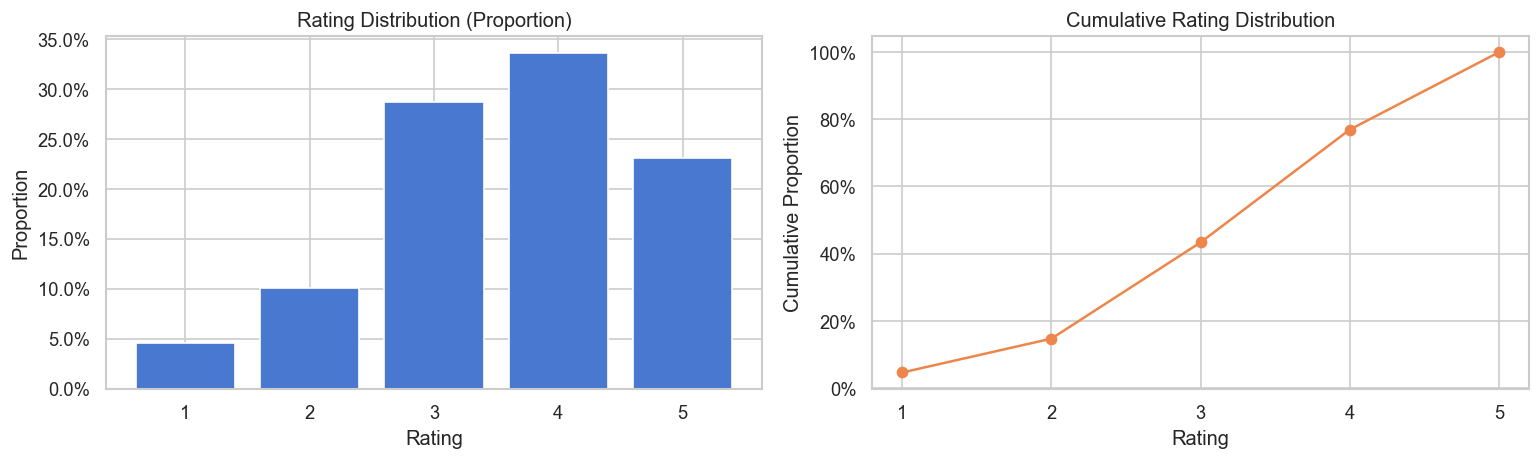

Mean rating:   3.604
Median rating: 4.0


In [15]:
rating_dist = df['rating'].value_counts(normalize=True).sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar chart
axes[0].bar(rating_dist.index, rating_dist.values, color=sns.color_palette("muted")[0], edgecolor="white")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Proportion")
axes[0].set_title("Rating Distribution (Proportion)")
axes[0].set_xticks(rating_dist.index)
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

# Cumulative
cumulative = rating_dist.cumsum()
axes[1].plot(cumulative.index, cumulative.values, marker='o', color=sns.color_palette("muted")[1])
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Cumulative Proportion")
axes[1].set_title("Cumulative Rating Distribution")
axes[1].set_xticks(rating_dist.index)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()

print(f"Mean rating:   {df['rating'].mean():.3f}")
print(f"Median rating: {df['rating'].median():.1f}")

**Key insight:** Ratings are heavily skewed toward positive values — over 50% of all ratings are 4 or 5 stars. This positive bias is common in recommendation datasets: users tend to rate movies they chose to watch, which already implies some pre-selection.

This imbalance matters for modeling — a naive baseline that always predicts 4 would already achieve a low RMSE. It also informs the choice of evaluation threshold in `02_preprocessing.ipynb`.

## 5. Movie Popularity Distribution

Not all movies are equally popular. Understanding the distribution of ratings per movie reveals whether a small set of titles dominates the dataset (a common pattern known as the long tail).

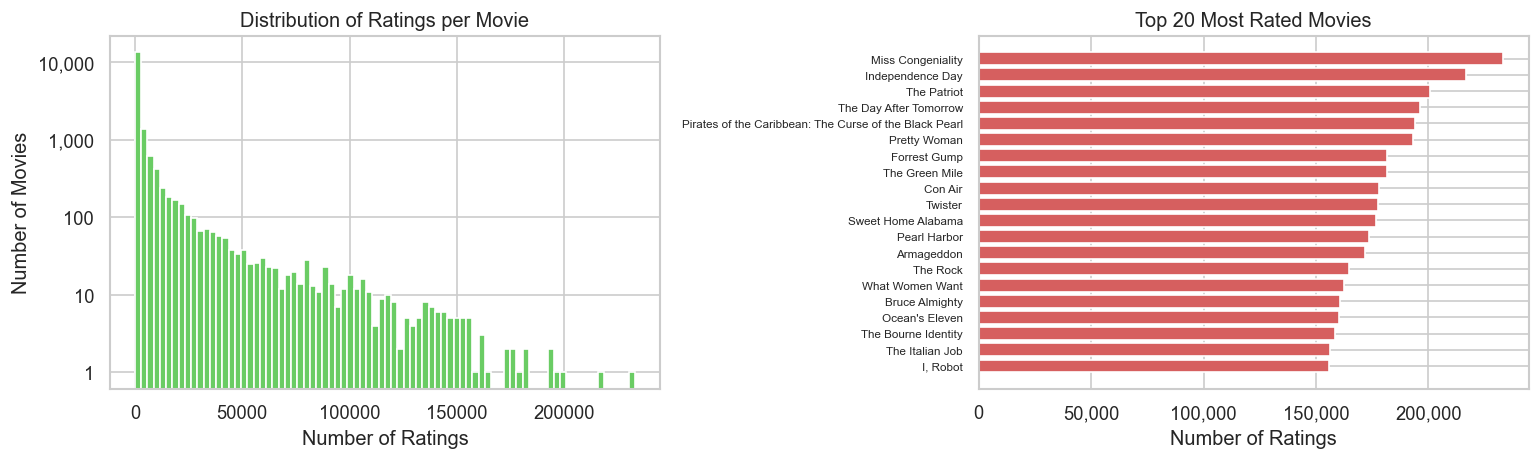

count     17,770
mean       5,655
std       16,910
min            3
25%          192
50%          561
75%        2,668
max      232,944
Name: rating, dtype: object


In [16]:
ratings_per_movie = df.groupby('movie_id')['rating'].count().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram — log scale to show the long tail, but with readable Y labels
axes[0].hist(ratings_per_movie.values, bins=80, color=sns.color_palette("muted")[2], edgecolor="white")
axes[0].set_xlabel("Number of Ratings")
axes[0].set_ylabel("Number of Movies")
axes[0].set_title("Distribution of Ratings per Movie")
axes[0].set_yscale("log")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Top 20 most rated
top_movies = ratings_per_movie.head(20).reset_index()
top_movies = top_movies.merge(movie_titles, left_on='movie_id', right_on='id', how='left')
top_movies['label'] = top_movies['title'].fillna(top_movies['movie_id'].astype(str))

axes[1].barh(top_movies['label'][::-1], top_movies['rating'][::-1], color=sns.color_palette("muted")[3])
axes[1].set_xlabel("Number of Ratings")
axes[1].set_title("Top 20 Most Rated Movies")
axes[1].tick_params(axis='y', labelsize=7)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

print(ratings_per_movie.describe().apply(lambda x: f'{x:,.0f}'))

**Key insight:** The distribution follows a classic **long tail** — a small number of movies receive the vast majority of ratings, while most movies have very few interactions.

Movies with very few ratings don't provide enough signal for a model to learn a reliable embedding. This motivates applying a `min_movie_ratings` threshold during preprocessing to remove them. The value of **50** is chosen conservatively: it eliminates the noisiest tail while retaining the bulk of the catalog.

## 6. User Activity Distribution

Similarly, user activity varies widely. Some users rate hundreds of movies; most rate only a handful.

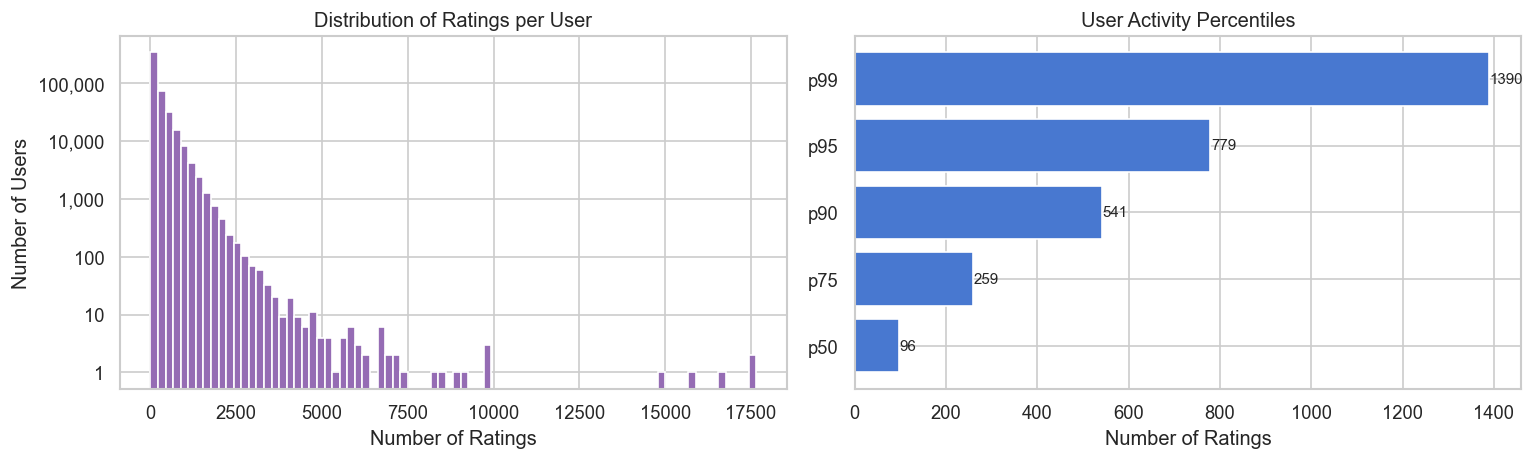

count    480,189
mean         209
std          302
min            1
25%           39
50%           96
75%          259
max       17,653
Name: rating, dtype: object


In [21]:
ratings_per_user = df.groupby('customer_id')['rating'].count().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram with readable Y labels
axes[0].hist(ratings_per_user.values, bins=80, color=sns.color_palette("muted")[4], edgecolor="white")
axes[0].set_xlabel("Number of Ratings")
axes[0].set_ylabel("Number of Users")
axes[0].set_title("Distribution of Ratings per User")
axes[0].set_yscale("log")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Percentile breakdown
percentiles = [50, 75, 90, 95, 99]
vals = np.percentile(ratings_per_user.values, percentiles)
axes[1].barh([f"p{p}" for p in percentiles], vals, color=sns.color_palette("muted")[0])
axes[1].set_xlabel("Number of Ratings")
axes[1].set_title("User Activity Percentiles")
for i, v in enumerate(vals):
    axes[1].text(v + 1, i, f"{v:.0f}", va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(ratings_per_user.describe().apply(lambda x: f'{x:,.0f}'))

**Key insight:** User activity is highly skewed — the histogram shows that most users have very few ratings, while a small number of power users have thousands. The percentile chart confirms this: the median user (p50) has rated very few movies, but by p99 the count jumps dramatically.

Users with fewer than 10 ratings suffer from the **cold start problem**: there isn't enough signal to learn a meaningful preference profile. This motivates the `min_user_ratings=10` threshold in `02_preprocessing.ipynb`.

## 7. Best and Worst Rated Movies

Looking at average ratings per movie reveals which titles users consistently love or dislike — though we need to be careful: a movie with 3 ratings averaging 5.0 is less reliable than one with 10,000 ratings averaging 4.7.

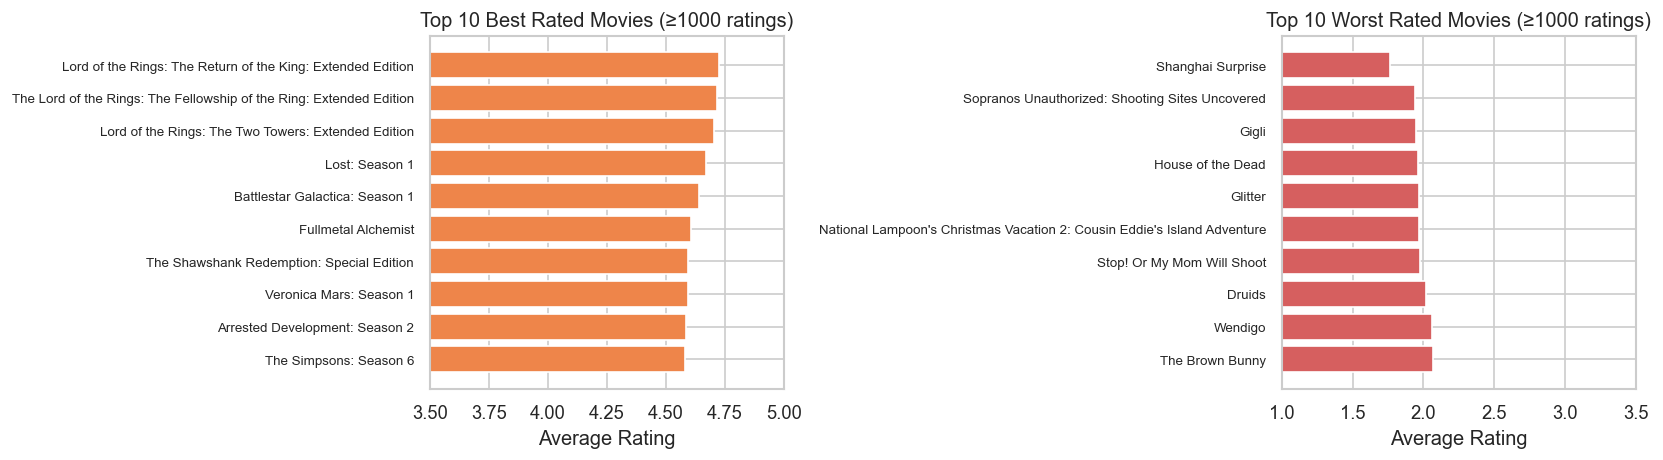

In [18]:
avg_rating = df.groupby('movie_id').agg(
    avg_rating=('rating', 'mean'),
    num_ratings=('rating', 'count')
).reset_index()

avg_rating = avg_rating.merge(movie_titles, left_on='movie_id', right_on='id', how='left')
avg_rating['label'] = avg_rating['title'].fillna(avg_rating['movie_id'])

# Filter to movies with enough ratings for reliability
reliable = avg_rating[avg_rating['num_ratings'] >= 1000].copy()

best  = reliable.nlargest(10, 'avg_rating')
worst = reliable.nsmallest(10, 'avg_rating')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].barh(best['label'][::-1], best['avg_rating'][::-1], color=sns.color_palette("muted")[1])
axes[0].set_xlabel("Average Rating")
axes[0].set_title("Top 10 Best Rated Movies (≥1000 ratings)")
axes[0].set_xlim(3.5, 5)
axes[0].tick_params(axis='y', labelsize=8)

axes[1].barh(worst['label'][::-1], worst['avg_rating'][::-1], color=sns.color_palette("muted")[3])
axes[1].set_xlabel("Average Rating")
axes[1].set_title("Top 10 Worst Rated Movies (≥1000 ratings)")
axes[1].set_xlim(1, 3.5)
axes[1].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

**Key insight:** We filter to movies with at least 1,000 ratings to ensure statistical reliability. The best-rated movies tend to be critically acclaimed titles, while the worst-rated ones are often direct-to-video or low-budget productions. This confirms the dataset reflects genuine user preferences rather than noise.

## 8. Rating Activity Over Time

The dataset spans from 1999 to 2005. Understanding how rating volume evolved over time motivates our choice of **temporal train/test split** — training on older data and evaluating on newer data better simulates real production conditions.

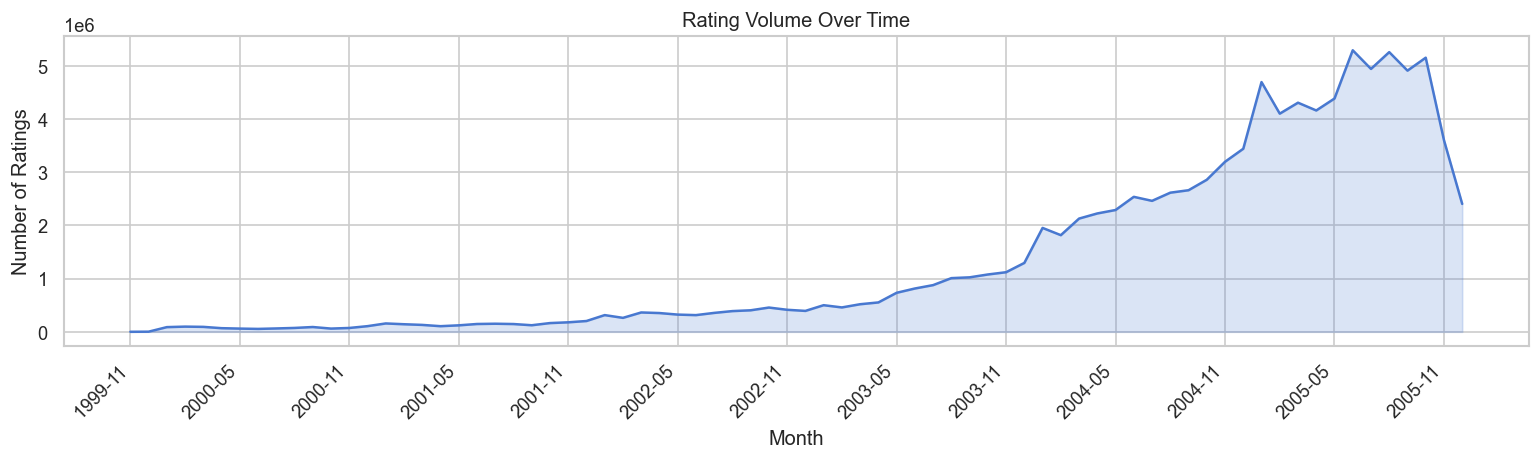

In [19]:
df['year_month'] = df['date'].dt.to_period('M')
ratings_over_time = df.groupby('year_month').size()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(ratings_over_time.index.astype(str), ratings_over_time.values,
        color=sns.color_palette("muted")[0], linewidth=1.5)
ax.fill_between(ratings_over_time.index.astype(str), ratings_over_time.values,
                alpha=0.2, color=sns.color_palette("muted")[0])
ax.set_xlabel("Month")
ax.set_ylabel("Number of Ratings")
ax.set_title("Rating Volume Over Time")

# Show only every 6th label to avoid crowding
ticks = ratings_over_time.index.astype(str)
ax.set_xticks(range(0, len(ticks), 6))
ax.set_xticklabels([ticks[i] for i in range(0, len(ticks), 6)], rotation=45, ha='right')

plt.tight_layout()
plt.show()

**Key insight:** Rating activity grew significantly over time, peaking around 2005. This temporal pattern is important for model evaluation: using a **random train/test split** would leak future information into training, artificially inflating metrics and misrepresenting real-world performance.

This motivates using a **temporal split** in `02_preprocessing.ipynb` — training on older ratings and evaluating on the most recent ones simulates how the model would actually perform in production.

## 9. Matrix Sparsity

Recommendation systems operate on a user-movie interaction matrix. Understanding its sparsity is key — the sparser the matrix, the harder it is for models to learn meaningful patterns.

In [20]:
n_users   = df['customer_id'].nunique()
n_movies  = df['movie_id'].nunique()
n_ratings = len(df)
possible  = n_users * n_movies
sparsity  = 1 - (n_ratings / possible)

print(f"Users:             {n_users:,}")
print(f"Movies:            {n_movies:,}")
print()
print(f"Observed ratings:  {n_ratings:,}")
print(f"Possible pairs:    {possible:,}   ← all unique (user, movie) combinations: {n_users:,} × {n_movies:,}")
print()
print(f"Density:           {1 - sparsity:.2%}   ← fraction of pairs that HAVE a rating")
print(f"Sparsity:          {sparsity:.2%}   ← fraction of pairs with NO rating (unknown)")

Users:             480,189
Movies:            17,770

Observed ratings:  100,480,507
Possible pairs:    8,532,958,530   ← all unique (user, movie) combinations: 480,189 × 17,770

Density:           1.18%   ← fraction of pairs that HAVE a rating
Sparsity:          98.82%   ← fraction of pairs with NO rating (unknown)


**Key insight:** Imagine a grid where every row is a user and every column is a movie — each cell would be a rating. **Possible pairs** is the total number of cells in that grid. **Density** is the fraction of cells that are filled; **sparsity** is the fraction that are empty (the user never rated that movie).

With ~98% sparsity, almost the entire grid is blank — the model's job is to intelligently fill in those blanks. This is exactly the problem collaborative filtering (SVD, NCF) is designed to solve.

## 10. Summary and Preprocessing Decisions

| Finding | Preprocessing decision |
|---------|------------------------|
| Ratings are valid integers in [1, 5] — no out-of-range values | Filter to `rating.between(1, 5)` as a safety check |
| Movie popularity follows a long tail | Drop movies with fewer than **50** ratings (`min_movie_ratings=50`) |
| User activity is highly skewed — cold start is a real issue | Drop users with fewer than **10** ratings (`min_user_ratings=10`) |
| Rating volume grew significantly over time | Use a **temporal train/test split** instead of a random one |
| Raw matrix sparsity > 98% | Collaborative filtering (SVD, NCF) is the right model family |

These decisions are implemented in `02_preprocessing.ipynb`.